# Delta-Target Diagnostic - Kathmandu AQI Project


## 1. Load data and recreate the same folds

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/kathmandu_features.csv")
df["datetime_utc"] = pd.to_datetime(df["datetime_utc"])
df = df.sort_values("datetime_utc").reset_index(drop=True)

target_column = "target_pm25_next_1h"
feature_columns = [col for col in df.columns if col not in ["datetime_utc", target_column]]

X = df[feature_columns]
y_absolute = df[target_column]           # original target: absolute next-hour value
current_pm25 = df["pm25"]
y_delta = y_absolute - current_pm25      # new target: the CHANGE from now to next hour
dates = df["datetime_utc"]

print("Delta target stats:")
print(y_delta.describe())

n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

Delta target stats:
count    8312.000000
mean        0.001362
std        17.443704
min      -142.100000
25%        -5.500000
50%         0.100000
75%         5.800000
max       190.400000
dtype: float64


## 2. Train on delta target, evaluate by reconstructing the absolute prediction

In [2]:
delta_results = []

for fold_num, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_delta_train = y_delta.iloc[train_idx]
    y_absolute_test = y_absolute.iloc[test_idx]
    current_pm25_test = current_pm25.iloc[test_idx]

    # y_delta can be NaN if either y_absolute or current_pm25 was NaN for that row.
    # Random Forest cannot accept NaN in the target, so these rows are dropped from training.
    train_valid_mask = ~y_delta_train.isna()
    X_train = X_train[train_valid_mask]
    y_delta_train = y_delta_train[train_valid_mask]

    imputer = SimpleImputer(strategy="median")
    X_train_imputed = imputer.fit_transform(X_train)
    X_test_imputed = imputer.transform(X_test)

    model = RandomForestRegressor(random_state=42, n_jobs=-1)
    model.fit(X_train_imputed, y_delta_train)

    predicted_delta = model.predict(X_test_imputed)
    predicted_absolute = current_pm25_test.values + predicted_delta

    # current_pm25_test can contain NaN (real sensor gaps), which propagates into
    # predicted_absolute. Drop those rows before scoring, same as the persistence baseline does.
    valid_mask = ~np.isnan(predicted_absolute)

    rmse = np.sqrt(mean_squared_error(y_absolute_test[valid_mask], predicted_absolute[valid_mask]))
    mae = mean_absolute_error(y_absolute_test[valid_mask], predicted_absolute[valid_mask])
    r2 = r2_score(y_absolute_test[valid_mask], predicted_absolute[valid_mask])

    delta_results.append({"fold": fold_num, "rmse_delta_model": rmse, "mae_delta_model": mae, "r2_delta_model": r2})

    print(f"Fold {fold_num}: Delta-target RF -> RMSE={rmse:.2f} MAE={mae:.2f} R2={r2:.3f}")

delta_df = pd.DataFrame(delta_results)

Fold 1: Delta-target RF -> RMSE=20.52 MAE=13.92 R2=0.761
Fold 2: Delta-target RF -> RMSE=19.59 MAE=13.84 R2=0.708
Fold 3: Delta-target RF -> RMSE=19.17 MAE=12.46 R2=0.822
Fold 4: Delta-target RF -> RMSE=12.84 MAE=9.17 R2=0.393
Fold 5: Delta-target RF -> RMSE=6.31 MAE=4.29 R2=0.661


## 3. Compare against naive persistence (same folds, same metric basis)

In [3]:
persist_results = []

for fold_num, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
    y_absolute_test = y_absolute.iloc[test_idx]
    current_pm25_test = current_pm25.iloc[test_idx]

    valid_mask = ~current_pm25_test.isna()

    rmse_p = np.sqrt(mean_squared_error(y_absolute_test[valid_mask], current_pm25_test[valid_mask]))
    mae_p = mean_absolute_error(y_absolute_test[valid_mask], current_pm25_test[valid_mask])
    r2_p = r2_score(y_absolute_test[valid_mask], current_pm25_test[valid_mask])

    persist_results.append({"fold": fold_num, "rmse_persist": rmse_p, "mae_persist": mae_p, "r2_persist": r2_p})

persist_df = pd.DataFrame(persist_results)

final_comparison = delta_df.merge(persist_df, on="fold")
print(final_comparison.to_string(index=False))

print()
print("=== AVERAGES ===")
print(f"Delta-target Random Forest : RMSE={final_comparison['rmse_delta_model'].mean():.2f}  MAE={final_comparison['mae_delta_model'].mean():.2f}  R2={final_comparison['r2_delta_model'].mean():.3f}")
print(f"Naive persistence          : RMSE={final_comparison['rmse_persist'].mean():.2f}  MAE={final_comparison['mae_persist'].mean():.2f}  R2={final_comparison['r2_persist'].mean():.3f}")

improvement = (1 - final_comparison['rmse_delta_model'].mean() / final_comparison['rmse_persist'].mean()) * 100
print(f"\nRMSE improvement over persistence: {improvement:.1f}%")

if improvement > 0:
    print("\u2705 Delta-target reframing BEATS naive persistence — this is a viable baseline approach.")
else:
    print("\n\u26a0\ufe0f  Delta-target reframing still does not beat persistence.")

 fold  rmse_delta_model  mae_delta_model  r2_delta_model  rmse_persist  mae_persist  r2_persist
    1         20.516389        13.915423        0.761378     25.797088    17.773994    0.622732
    2         19.586297        13.840161        0.707979     18.837901    11.343080    0.729869
    3         19.172067        12.455825        0.821908     13.157190     8.314828    0.916125
    4         12.838388         9.168244        0.392652      7.738198     4.887962    0.779354
    5          6.306154         4.285703        0.661137      7.025198     4.672637    0.579455

=== AVERAGES ===
Delta-target Random Forest : RMSE=15.68  MAE=10.73  R2=0.669
Naive persistence          : RMSE=14.51  MAE=9.40  R2=0.726

RMSE improvement over persistence: -8.1%

⚠️  Delta-target reframing still does not beat persistence.


## 4. Feature importance for the delta model

Since the model now predicts the *change*, not the absolute value, `pm25` itself should matter far less — features that explain *why* pollution goes up or down (weather, time, lags) should become more prominent if this reframing worked as intended.

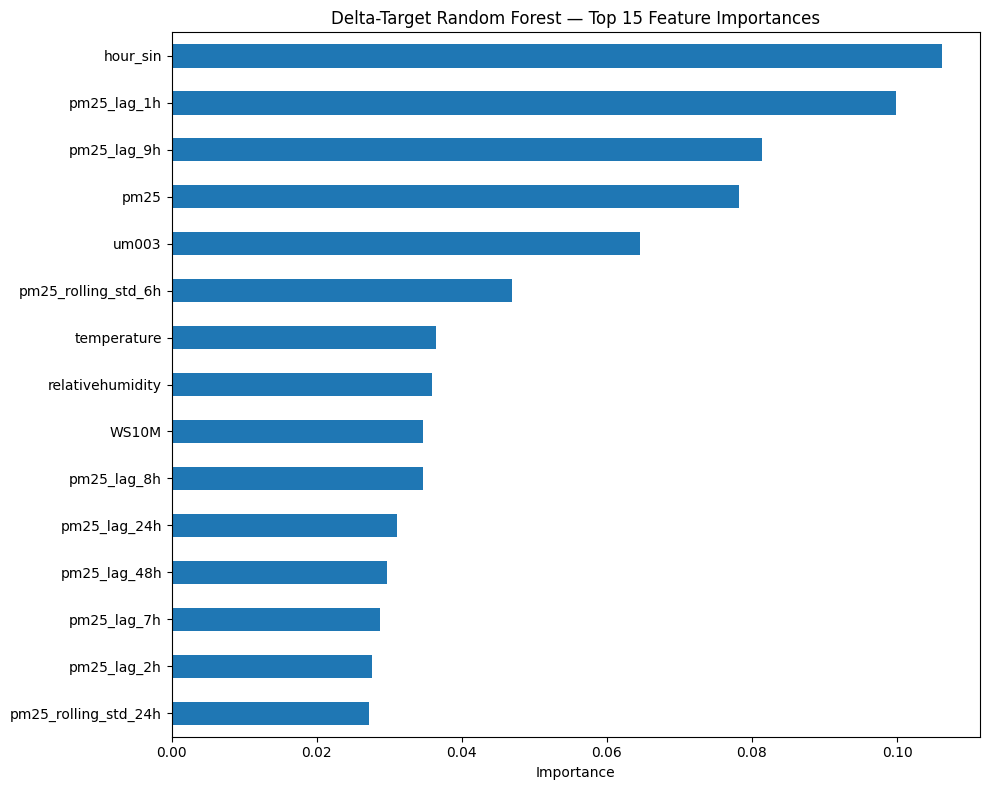

hour_sin                0.106132
pm25_lag_1h             0.099894
pm25_lag_9h             0.081425
pm25                    0.078190
um003                   0.064537
pm25_rolling_std_6h     0.046858
temperature             0.036418
relativehumidity        0.035953
WS10M                   0.034622
pm25_lag_8h             0.034591
pm25_lag_24h            0.031045
pm25_lag_48h            0.029629
pm25_lag_7h             0.028711
pm25_lag_2h             0.027670
pm25_rolling_std_24h    0.027214
dtype: float64


In [4]:
valid_mask_full = ~y_delta.isna()
X_valid = X[valid_mask_full]
y_delta_valid = y_delta[valid_mask_full]

imputer_full = SimpleImputer(strategy="median")
X_full_imputed = pd.DataFrame(imputer_full.fit_transform(X_valid), columns=X_valid.columns, index=X_valid.index)

final_delta_model = RandomForestRegressor(random_state=42, n_jobs=-1)
final_delta_model.fit(X_full_imputed, y_delta_valid)

importances_delta = pd.Series(final_delta_model.feature_importances_, index=feature_columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importances_delta.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Delta-Target Random Forest — Top 15 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(importances_delta.head(15))